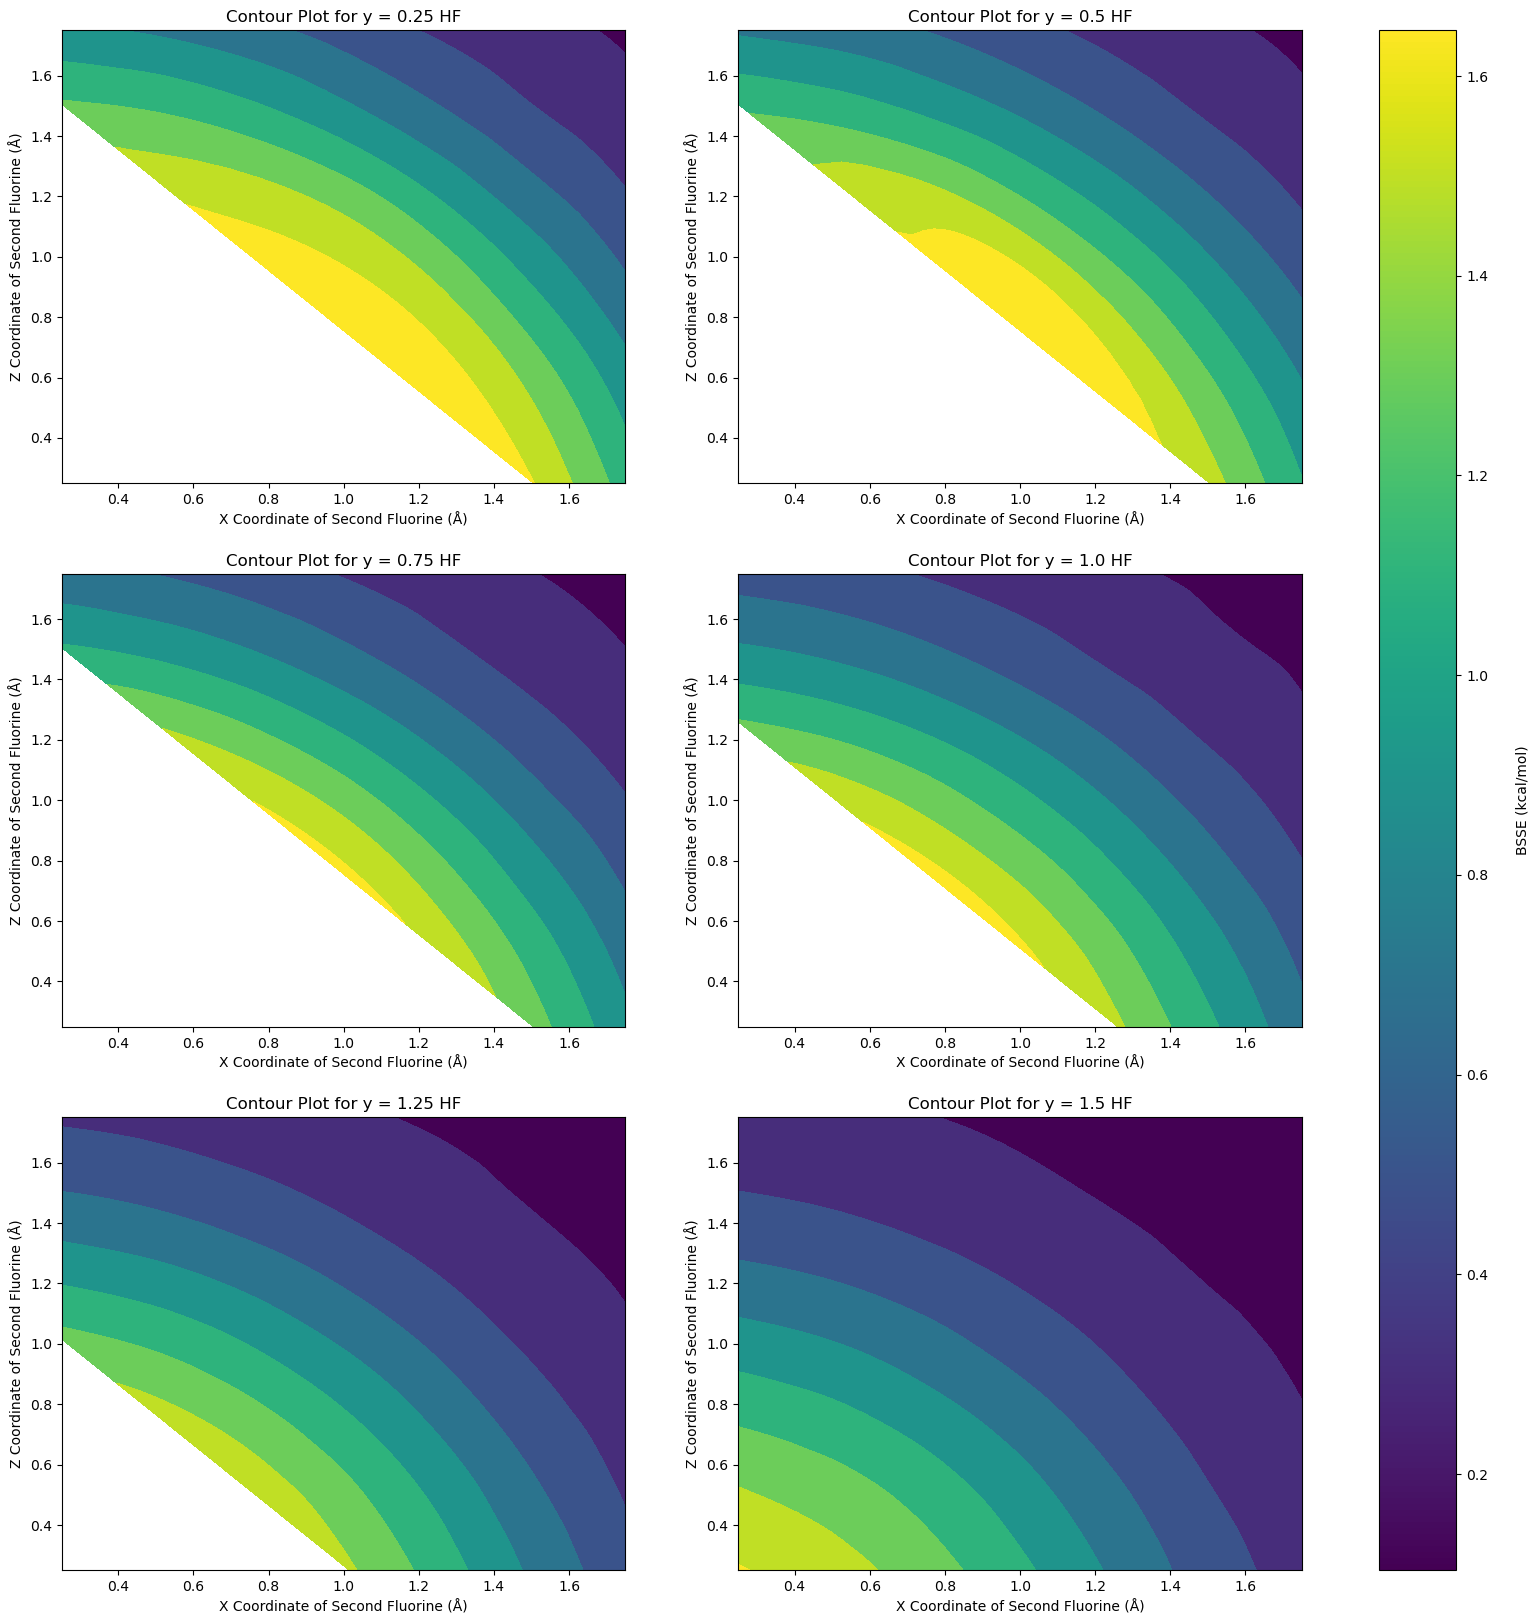

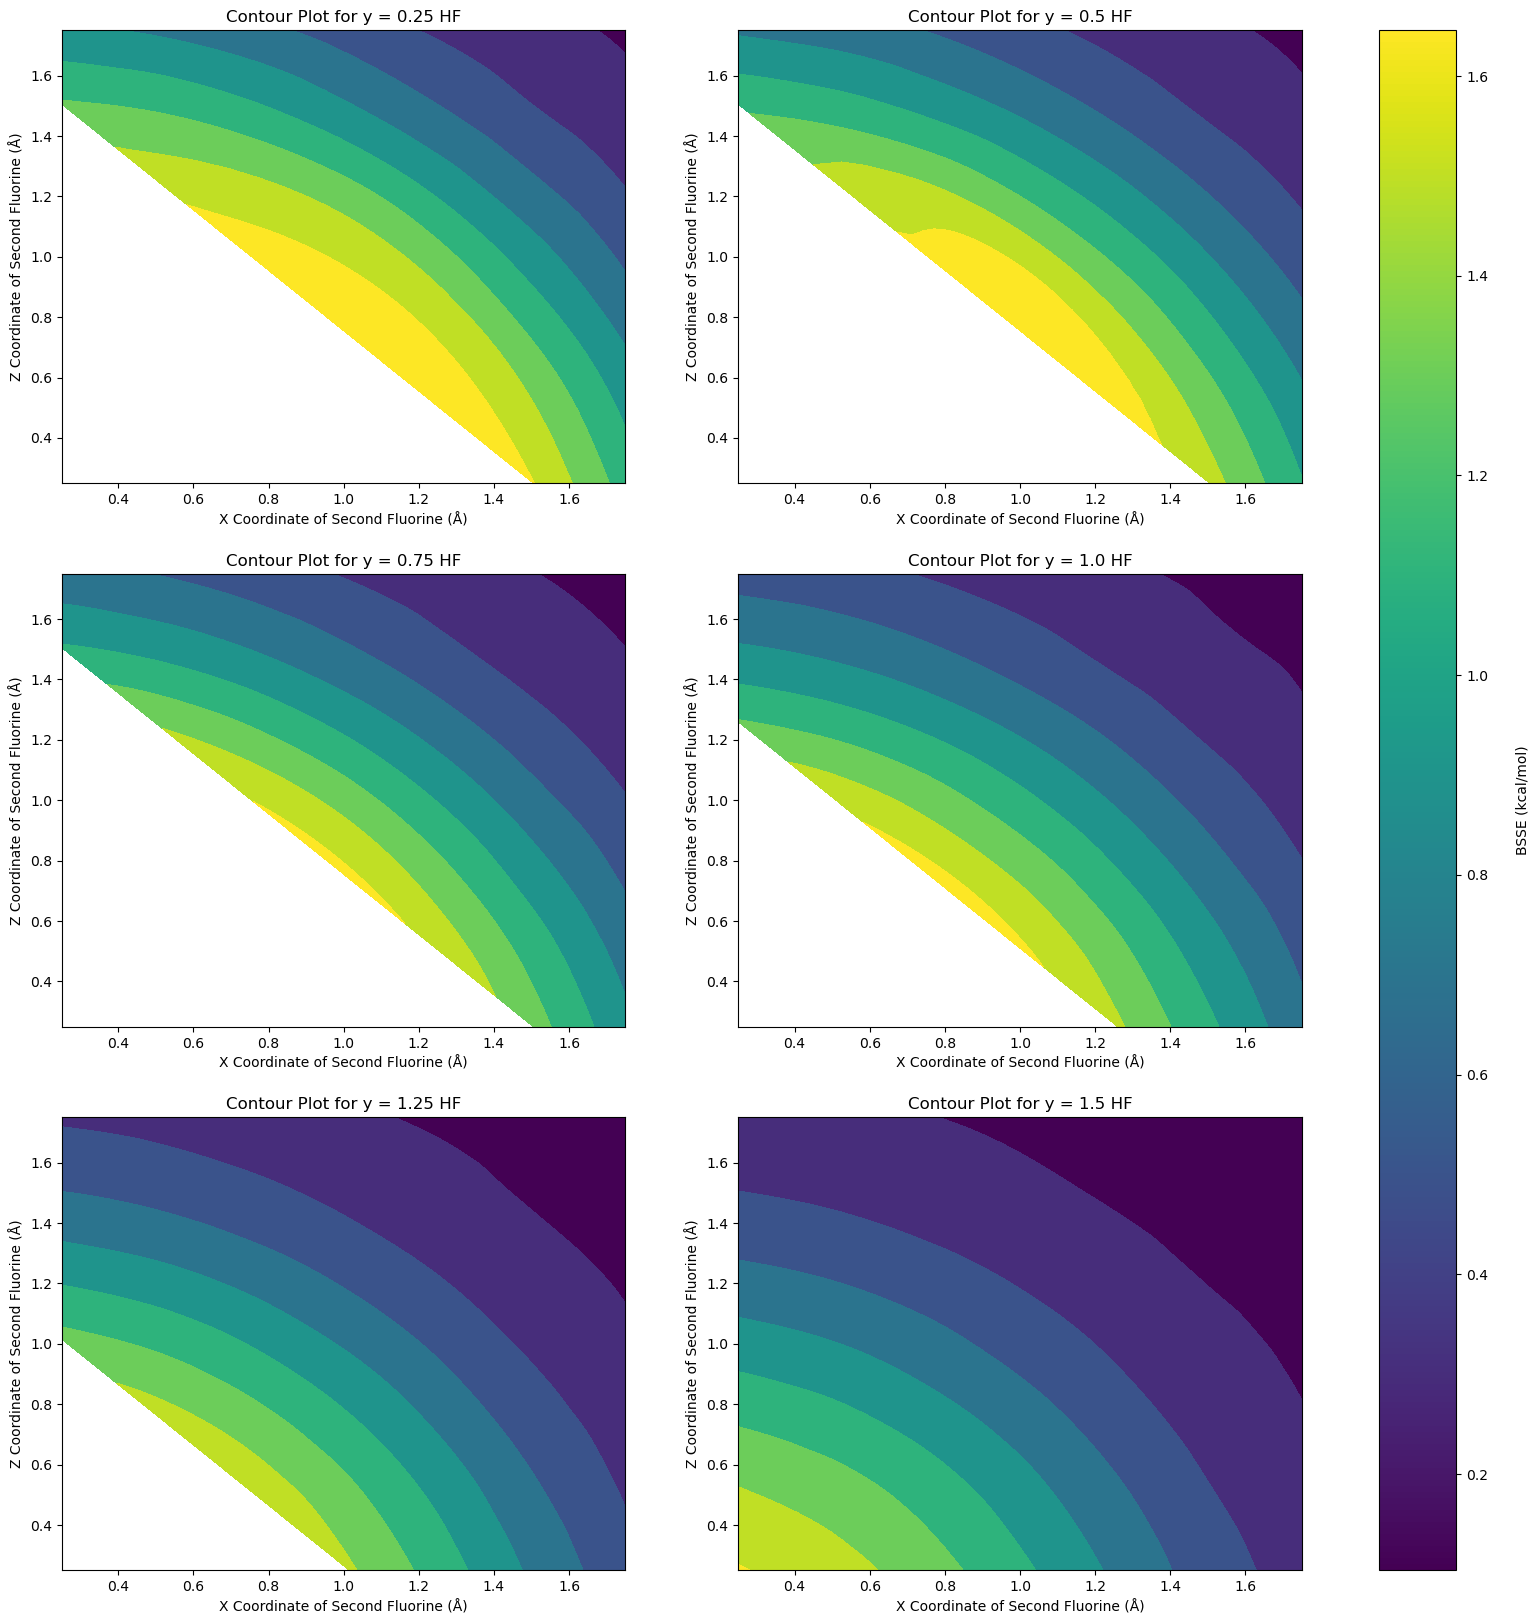

In [1]:
import pandas as pd
from bsse_calculator.plotting_helpers import (
    make_bsse_contour_plots,
    fit_gaussian,
    make_contour_plots_of_fitted_gaussian,
    predicted_v_actual_plot,
    make_error_contour_plots,
)

bsse_data_nwchem_kcal = pd.read_csv("BSSE_by_FF_distance_nwchem.csv")
bsse_data_nwchem_kcal["BSSE_A"] = bsse_data_nwchem_kcal["BSSE_A"] * 627.5096
bsse_data_nwchem_kcal["BSSE_B"] = bsse_data_nwchem_kcal["BSSE_B"] * 627.5096
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] * 627.5096
)
make_bsse_contour_plots(bsse_data_nwchem_kcal, "Fluorine", "HF")

In [1]:
import numpy as np

bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)

NameError: name 'bsse_data_nwchem_kcal' is not defined

In [ ]:
bsse_data_nwchem_kcal = bsse_data_nwchem_kcal.sort_values("distance")

     Delta_E_AB_AB    BSSE_A    BSSE_B     x     y     z
0         0.240631  0.003353  0.003041  0.25  2.00  0.25
1         0.152513  0.002846  0.002756  0.25  2.00  0.50
2         0.087499  0.002231  0.002267  0.25  2.00  0.75
3         0.047547  0.001668  0.001746  0.25  2.00  1.00
4         0.024525  0.001229  0.001284  0.25  2.00  1.25
..             ...       ...       ...   ...   ...   ...
191      -0.000717  0.000402  0.000476  1.75  2.75  0.75
192      -0.000888  0.000368  0.000405  1.75  2.75  1.00
193      -0.000958  0.000328  0.000335  1.75  2.75  1.25
194      -0.000923  0.000283  0.000271  1.75  2.75  1.50
195      -0.000808  0.000239  0.000218  1.75  2.75  1.75

[196 rows x 6 columns]
     Delta_E_AB_AB    BSSE_A    BSSE_B     x     y     z
0         0.138889  0.001960  0.001960  0.25  0.25  1.50
1         0.049314  0.001333  0.001333  0.25  0.25  1.75
2         0.110568  0.001860  0.001860  0.25  0.50  1.50
3         0.040435  0.001230  0.001230  0.25  0.50  1.75
4      

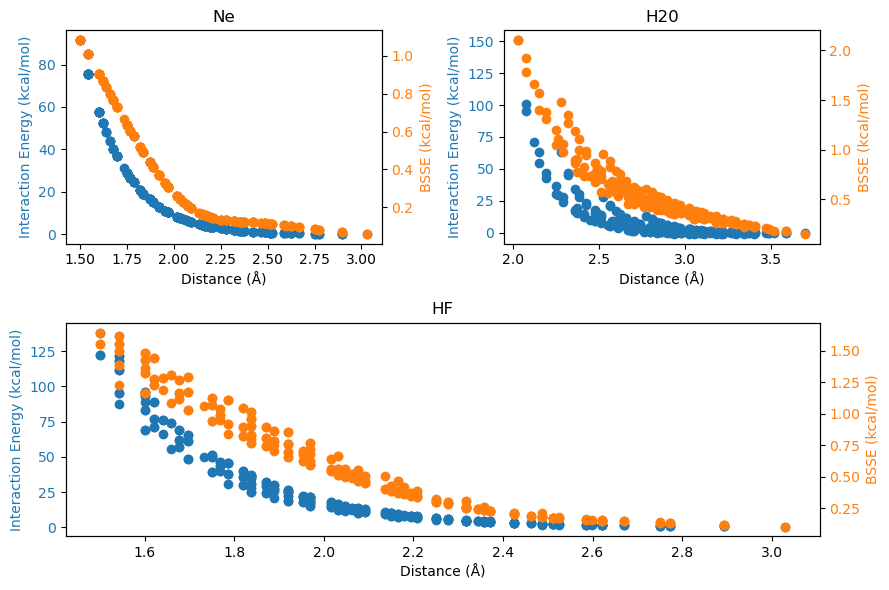

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from bsse_calculator.plotting_helpers import plot_dual_axis


def load_and_prepare_data(filename):
    df = pd.read_csv(filename)
    print(df)
    for col in ["BSSE_A", "BSSE_B", "Delta_E_AB_AB"]:
        df[col] = df[col] * 627.5096
    df["distance"] = np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)
    return df.sort_values("distance")


def load_and_prepare_data_Ne(filename):
    bsse_data_nwchem_kcal = pd.read_csv(filename)
    bsse_data_nwchem_kcal["BSSE_A"] = (
        bsse_data_nwchem_kcal["Total_energy_BSSE_A"].apply(
            lambda x: float(x.strip("()").split(",")[0])
        )
        * 627.5096
    )
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
        bsse_data_nwchem_kcal["Total_energy_Delta_E_AB_AB"].apply(
            lambda x: float(x.strip("()").split(",")[0])
        )
        * 627.5096
    )
    bsse_data_nwchem_kcal["distance"] = np.sqrt(
        bsse_data_nwchem_kcal["x"] ** 2
        + bsse_data_nwchem_kcal["y"] ** 2
        + bsse_data_nwchem_kcal["z"] ** 2
    )
    return bsse_data_nwchem_kcal


# File mapping
datasets = {
    "Ne": "../Ne/BSSE_by_Ne_Ne_distance_nwchem.csv",
    "H20": "../H20/BSSE_by_H2O_H2O_distance_nwchem_more_distances.csv",
    "HF": "BSSE_by_FF_distance_nwchem.csv",
}

fig = plt.figure(figsize=(6 * 3 / 2, 4 * 3 / 2))
gs = gridspec.GridSpec(2, 2)

# Axes layout
positions = [(0, 0), (0, 1), (1, slice(None))]

for (title, file), pos, load_and_prepare_data in zip(
    datasets.items(),
    positions,
    (load_and_prepare_data_Ne, load_and_prepare_data, load_and_prepare_data),
):
    df = load_and_prepare_data(file)

    ax = plt.subplot(gs[pos])

    # Use dual y-axes
    ax2 = ax.twinx()
    ax.scatter(
        df["distance"],
        df["Delta_E_AB_AB"],
        color="tab:blue",
        label="Interaction Energy",
    )
    ax2.scatter(df["distance"], df["BSSE_A"], color="tab:orange", label="BSSE")

    ax.set_xlabel("Distance (Å)")
    ax.set_ylabel("Interaction Energy (kcal/mol)", color="tab:blue")
    ax2.set_ylabel("BSSE (kcal/mol)", color="tab:orange")
    ax.set_title(title)

    # Optional: synchronize limits or legends
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.tight_layout()
plt.show()

([<matplotlib.collections.PathCollection at 0x13e99fb50>,
 ['Interaction Energy', 'BSSE'])

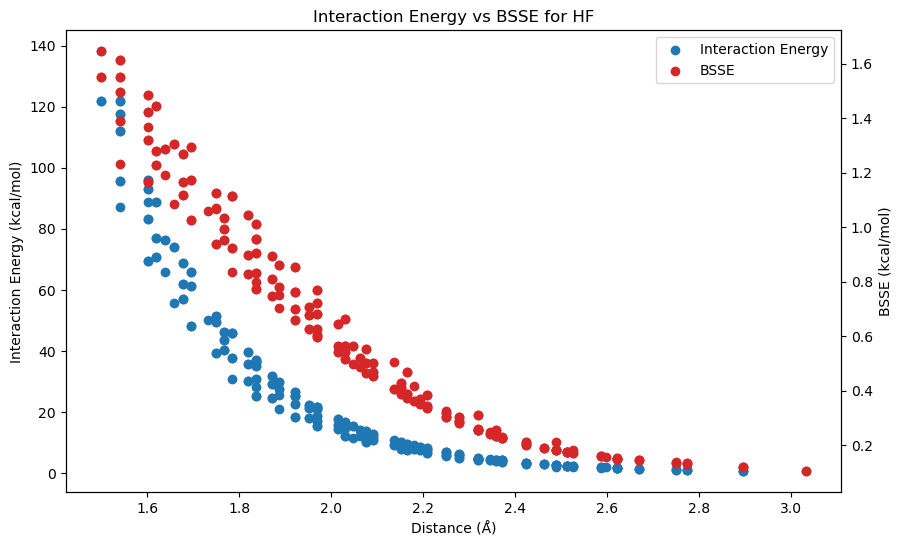

In [ ]:
from bsse_calculator.plotting_helpers import *

bsse_data_nwchem_kcal = pd.read_csv("BSSE_by_FF_distance_nwchem.csv")
bsse_data_nwchem_kcal["BSSE_A"] = bsse_data_nwchem_kcal["BSSE_A"] * 627.5096
bsse_data_nwchem_kcal["BSSE_B"] = bsse_data_nwchem_kcal["BSSE_B"] * 627.5096
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] * 627.5096
)
import numpy as np

bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)
bsse_data_nwchem_kcal = bsse_data_nwchem_kcal.sort_values("distance")
plot_dual_axis(
    bsse_data_nwchem_kcal["Delta_E_AB_AB"],
    bsse_data_nwchem_kcal["BSSE_A"],
    bsse_data_nwchem_kcal["distance"],
    type="scatter",
    x_label="Distance (Å)",
    y1_label="Interaction Energy (kcal/mol)",
    y2_label="BSSE (kcal/mol)",
    title="Interaction Energy vs BSSE for HF",
    label1="Interaction Energy",
    label2="BSSE",
)

In [2]:
fit_gauss = fit_gaussian(
    bsse_data_nwchem_kcal,
)

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


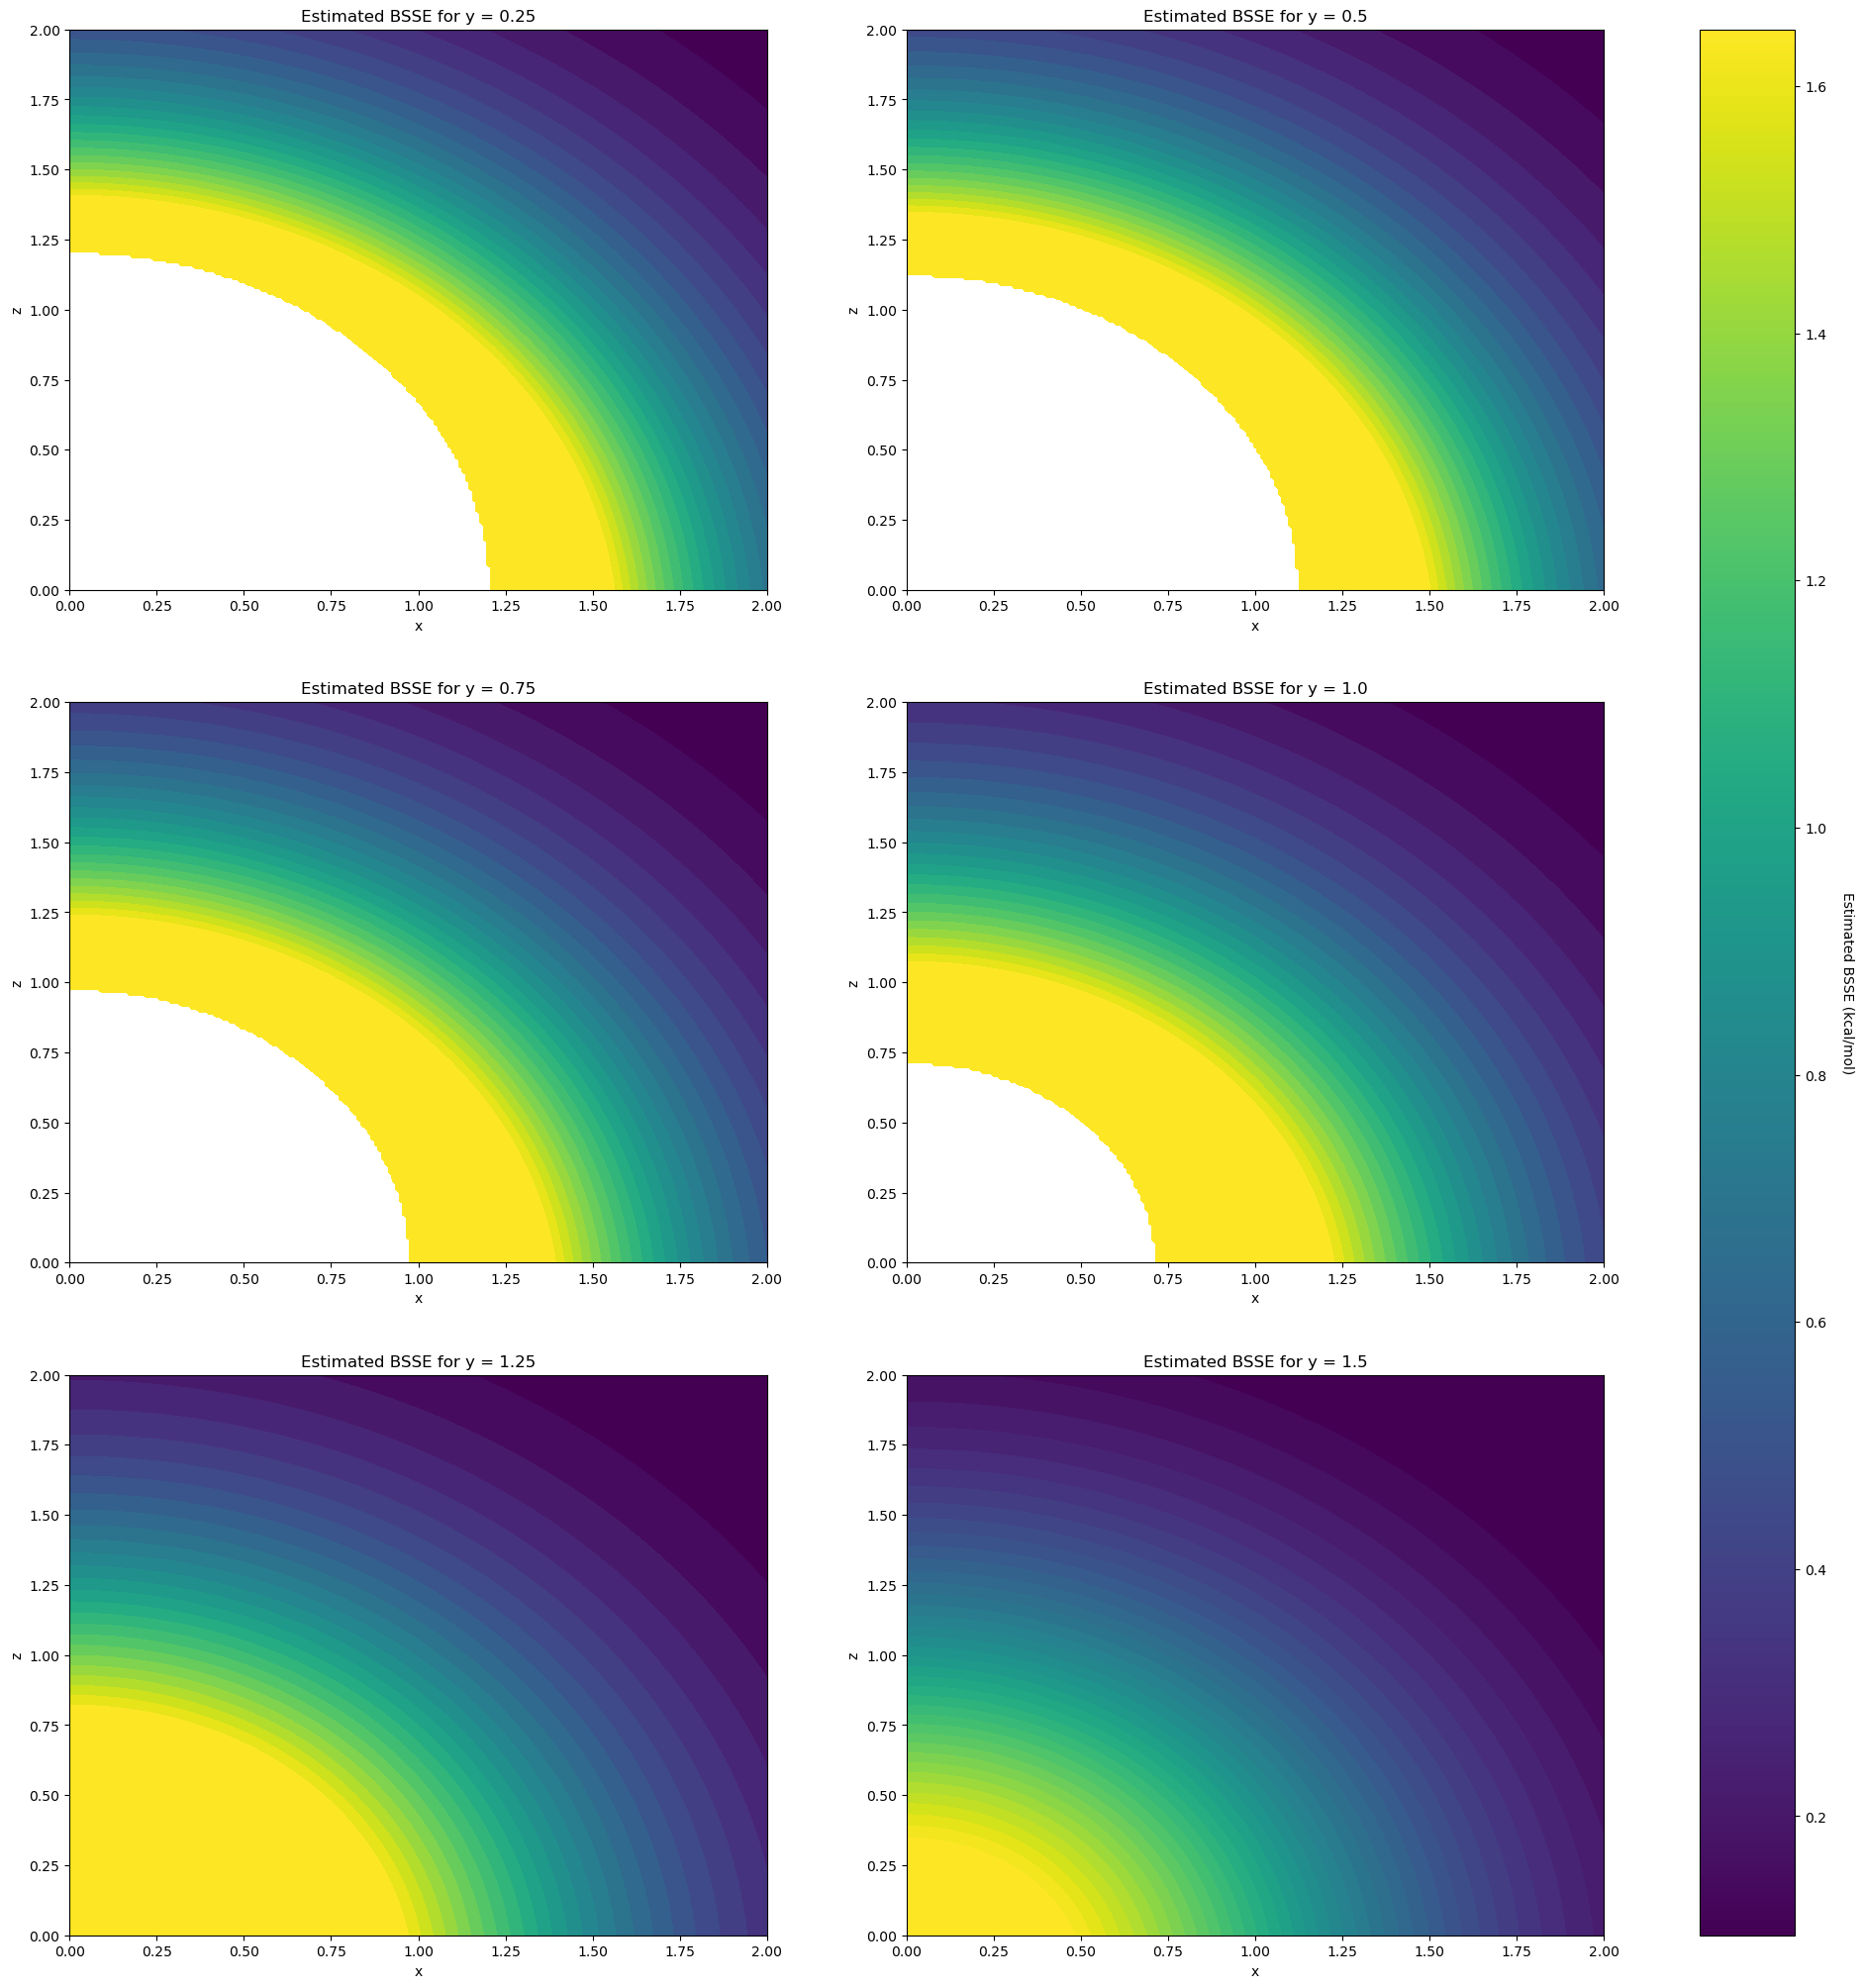

In [3]:
make_contour_plots_of_fitted_gaussian(bsse_data_nwchem_kcal, fit_gauss)

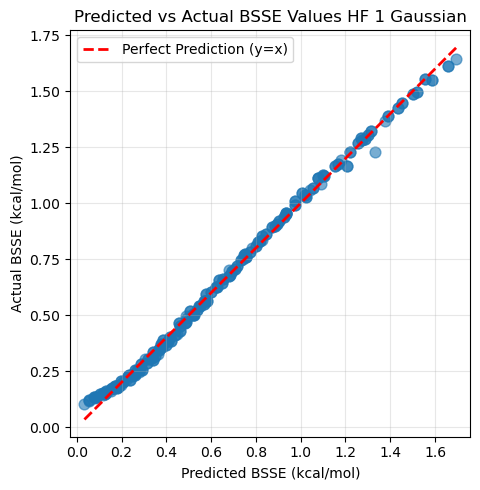

{'RMSE': np.float64(0.023008270470104855), 'MAE': np.float64(0.01785055235165454), '% Error': np.float64(5.69619369085415)}


/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


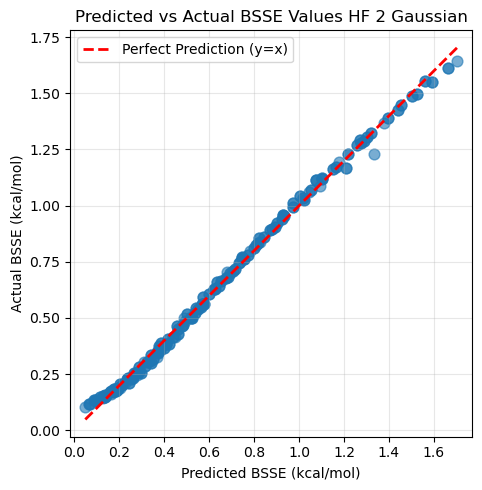

{'RMSE': np.float64(0.02260770689584895), 'MAE': np.float64(0.018163966565537964), '% Error': np.float64(5.271917619252482)}


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

In [14]:
for i in range(1, 4):
    fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, i)
    print(predicted_v_actual_plot(bsse_data_nwchem_kcal, fit_gauss, f"HF {i} Gaussian"))

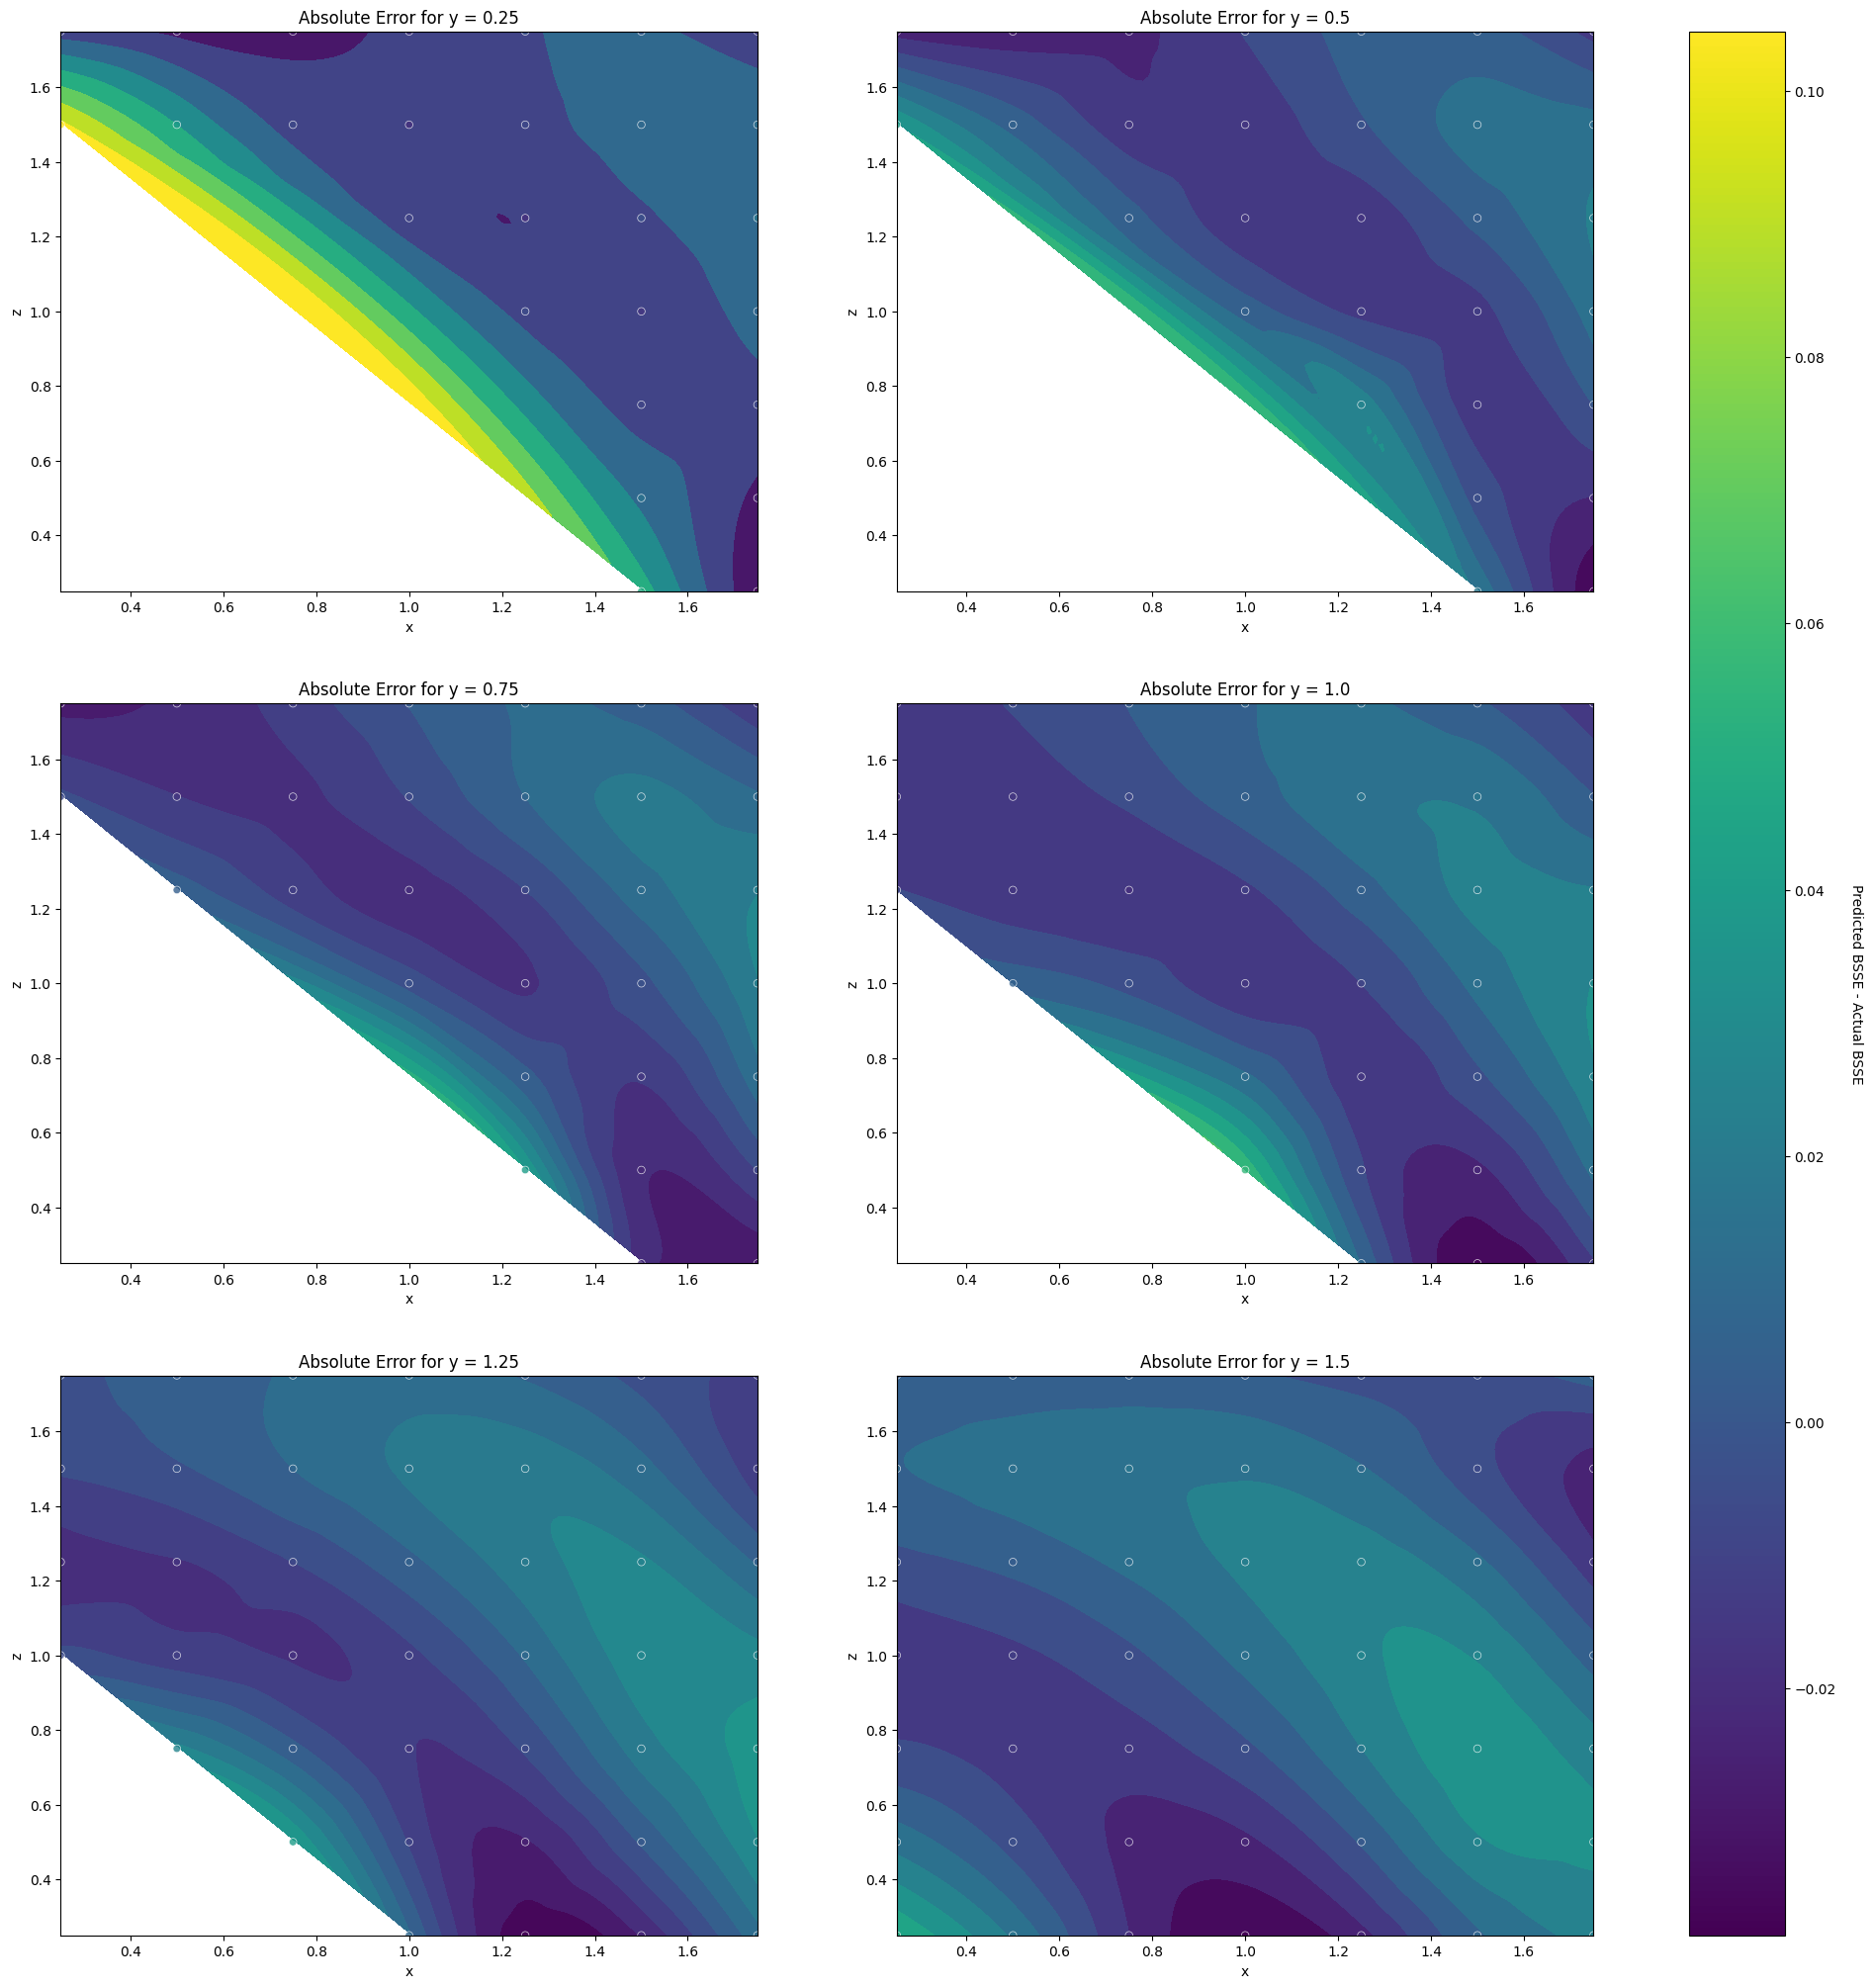

In [ ]:
make_error_contour_plots(bsse_data_nwchem_kcal, fit_gauss)

NameError: name 'json' is not defined

In [ ]:
df

,side_length,E(A)_A,E(A)_AB,E(A)_AC,E(A)_ABC,E(B)_B,E(B)_AB,E(B)_BC,E(B)_ABC,E(C)_C,E(C)_AC,E(C)_BC,E(C)_ABC,E(AB)_AB,E(AB)_ABC,E(AC)_AC,E(AC)_ABC,E(BC)_BC,E(BC)_ABC,E(ABC)_ABC
0,1.5,-62917.701096,-62919.432362,-62919.432362,-62921.258255,-62917.701096,-62919.432353,-62919.432362,-62921.258255,-62917.701096,-62919.432353,-62919.432353,-62921.258255,-125677.472202,-125681.914302,-125677.472202,-125681.914200,-125677.472202,-125681.914302,-188323.935433
1,1.75,-62917.701109,-62918.901387,-62918.901389,-62920.146559,-62917.701109,-62918.901397,-62918.901389,-62920.146558,-62917.701109,-62918.901397,-62918.901397,-62920.146558,-125775.149653,-125777.902282,-125775.149630,-125777.902295,-125775.149630,-125777.902283,-188585.926403
2,2.0,-62917.701111,-62918.452333,-62918.452342,-62919.240279,-62917.701111,-62918.452326,-62918.452342,-62919.240281,-62917.701111,-62918.452344,-62918.452344,-62919.240275,-125811.540268,-125813.190864,-125811.540270,-125813.190864,-125811.540270,-125813.190863,-188685.988061
3,2.25,-62917.701111,-62918.114481,-62918.114458,-62918.558417,-62917.701111,-62918.114428,-62918.114458,-62918.558431,-62917.701111,-62918.114464,-62918.114464,-62918.558431,-125825.166337,-125826.081008,-125825.166371,-125826.081008,-125825.166371,-125826.081009,-188724.091566
4,2.5,-62917.701111,-62917.946765,-62917.946762,-62918.219713,-62917.701111,-62917.946770,-62917.946762,-62918.219712,-62917.701111,-62917.946763,-62917.946763,-62918.219711,-125830.494374,-125831.055217,-125830.494373,-125831.055217,-125830.494373,-125831.055215,-188739.158559
5,2.75,-62917.701111,-62917.884323,-62917.884331,-62918.087949,-62917.701111,-62917.884321,-62917.884331,-62918.087949,-62917.701111,-62917.884324,-62917.884324,-62918.087949,-125832.744253,-125833.163085,-125832.744257,-125833.163085,-125832.744257,-125833.163086,-188745.545456
6,3.0,-62917.701111,-62917.836350,-62917.836333,-62917.982514,-62917.701111,-62917.836334,-62917.836333,-62917.982514,-62917.701111,-62917.836340,-62917.836340,-62917.982515,-125833.740289,-125834.040740,-125833.740270,-125834.040740,-125833.740270,-125834.040739,-188748.350164
7,3.25,-62917.701111,-62917.796956,-62917.796950,-62917.897273,-62917.701111,-62917.796957,-62917.796950,-62917.897271,-62917.701111,-62917.796935,-62917.796935,-62917.897271,-125834.220834,-125834.425818,-125834.220835,-125834.425818,-125834.220835,-125834.425820,-188749.690683
8,3.5,-62917.701111,-62917.774273,-62917.774268,-62917.848114,-62917.701111,-62917.774274,-62917.774268,-62917.848114,-62917.701111,-62917.774274,-62917.774274,-62917.848117,-125834.497266,-125834.646701,-125834.497249,-125834.646701,-125834.497249,-125834.646701,-188750.462620
9,3.75,-62917.701111,-62917.760462,-62917.760462,-62917.818338,-62917.701111,-62917.760441,-62917.760462,-62917.818340,-62917.701111,-62917.760441,-62917.760441,-62917.818338,-125834.677503,-125834.793746,-125834.677503,-125834.793746,-125834.677503,-125834.793747,-188750.970516


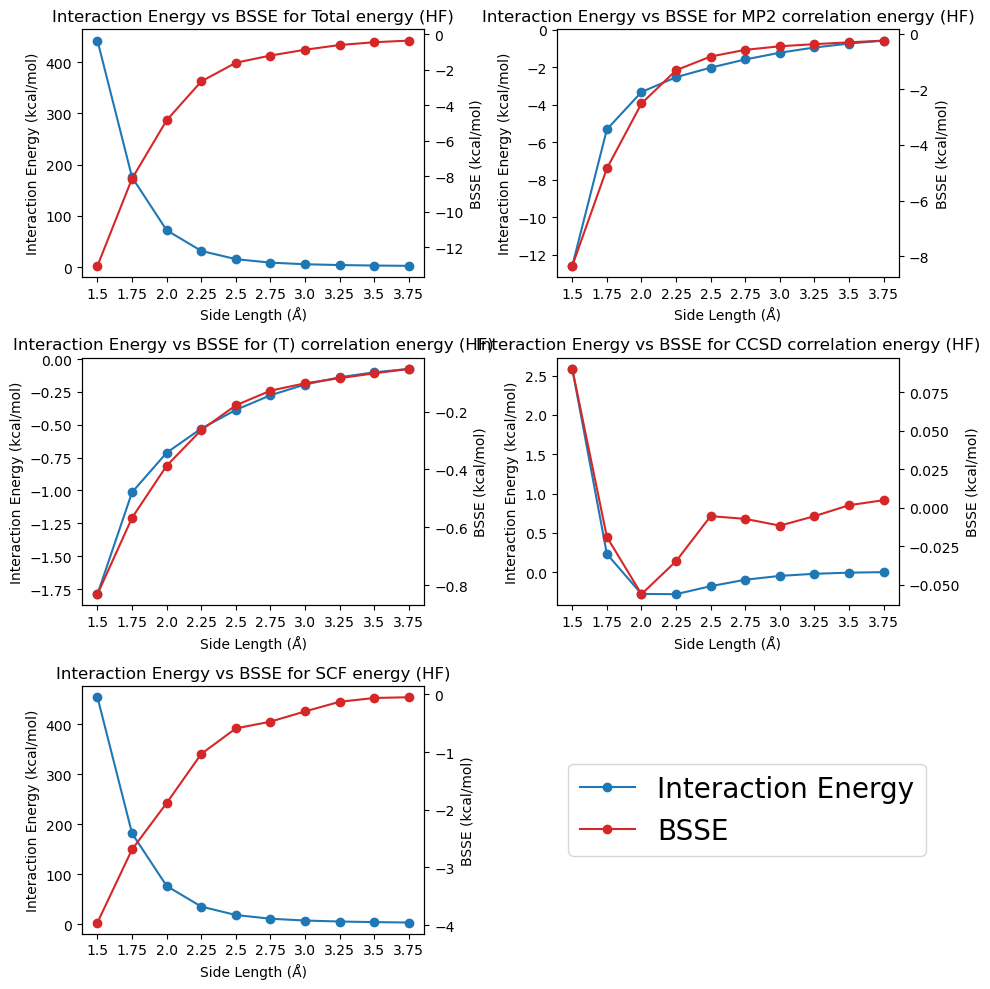

In [ ]:
import json
from bsse_calculator.plotting_helpers import *
from matplotlib import pyplot as plt

energies = json.loads(open("HF_trimer_energies.json", "r").read())
energy_dfs = create_df(energies)
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    df = TrimerBsseCalculator.switch_convention(df)
    df = create_BSSEs_and_interaction_energies(df)
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (HF)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
        show_legend=False,
    )
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

In [ ]:
class TrimerBsseCalculator:
    @staticmethod
    def calculate_monomer_bsse_one_approx(df):
        total_dimer_bsse = pd.Series(0, index=df.index)
        for monomer in ["A", "B", "C"]:
            total_dimer_bsse += df[f"E({monomer})_{monomer}"] - df[f"E(ABC)_{monomer}"]
        df["BSSE monomers (one body approximation)"] = total_dimer_bsse
        return df

    @staticmethod
    def calculate_monomer_bsse_two_approx(df):
        total_dimer_bsse = pd.Series(0, index=df.index)
        for monomer in ["A", "B", "C"]:
            two_body_approx = pd.Series(0, index=df.index)
            for dimer in combinations(["A", "B", "C"], 2):
                if monomer in dimer:
                    two_body_approx += df[f"E({dimer[0]}{dimer[1]})_{monomer}"] / 2
            total_dimer_bsse += two_body_approx - df[f"E(ABC)_{monomer}"]
        df["BSSE monomers (two body approximation)"] = total_dimer_bsse
        return df

    @staticmethod
    def calculate_dimer_two_approx(df):
        total_dimer_bsse = pd.Series(0, index=df.index)
        for dimer in combinations(["A", "B", "C"], 2):
            total_dimer_bsse += (
                df[f"Delta_E({dimer[0]}{dimer[1]})_{dimer[0]}{dimer[1]}"]
                - df[f"Delta_E(ABC)_{dimer[0]}{dimer[1]}"]
            )
        df["BSSE Dimers (two body approximation)"] = total_dimer_bsse
        return df

    @staticmethod
    def calculate_all_bsse(df):
        df = TrimerBsseCalculator.calculate_monomer_bsse_one_approx(df)
        df = TrimerBsseCalculator.calculate_monomer_bsse_two_approx(df)
        df = TrimerBsseCalculator.calculate_dimer_two_approx(df)
        return df

In [ ]:
from collections import defaultdict
import re
import json
from bsse_calculator.plotting_helpers import *

In [ ]:
def plot_bsse_composition_trimer(filename, monomer_name):
    energies = json.loads(open(filename, "r").read())
    new_energies = defaultdict(dict)
    for side_length, calculations in energies.items():
        for calculation_type, energies_types in calculations.items():
            match = re.search(r"\((.*?)\)", calculation_type)
            if match:
                result = match.group(1)  # 'afd'
            else:
                raise Exception
            monomers = result.replace("_", "")
            basis = (
                calculation_type.replace(f"E({result})", "")
                .replace("_", "")
                .replace("E(", "")
                .replace(")", "")
            )
            new_energies[side_length][f"E({basis})_{monomers}"] = energies_types
    energy_dfs = create_df(new_energies)
    energy_dfs = {
        k: create_BSSEs_and_interaction_energies(df) for k, df in energy_dfs.items()
    }
    energy_dfs = {
        k: TrimerBsseCalculator.calculate_all_bsse(df) for k, df in energy_dfs.items()
    }
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, (k, df) in zip(axes, energy_dfs.items()):
        formated_title = k.replace("_", " ")
        tmp_df = df[
            [
                "side_length",
                "BSSE monomers (one body approximation)",
                "BSSE monomers (two body approximation)",
                "BSSE Dimers (two body approximation)",
            ]
        ]
        tmp_df.plot(x="side_length", ax=ax, kind="bar")
        ax.set_title(f"BSSE for {formated_title} ({monomer_name})")
    plt.suptitle(f"BSSE components for Trimer ({monomer_name})", fontsize=20)
    plt.tight_layout()
    fig.delaxes(axes[-1])

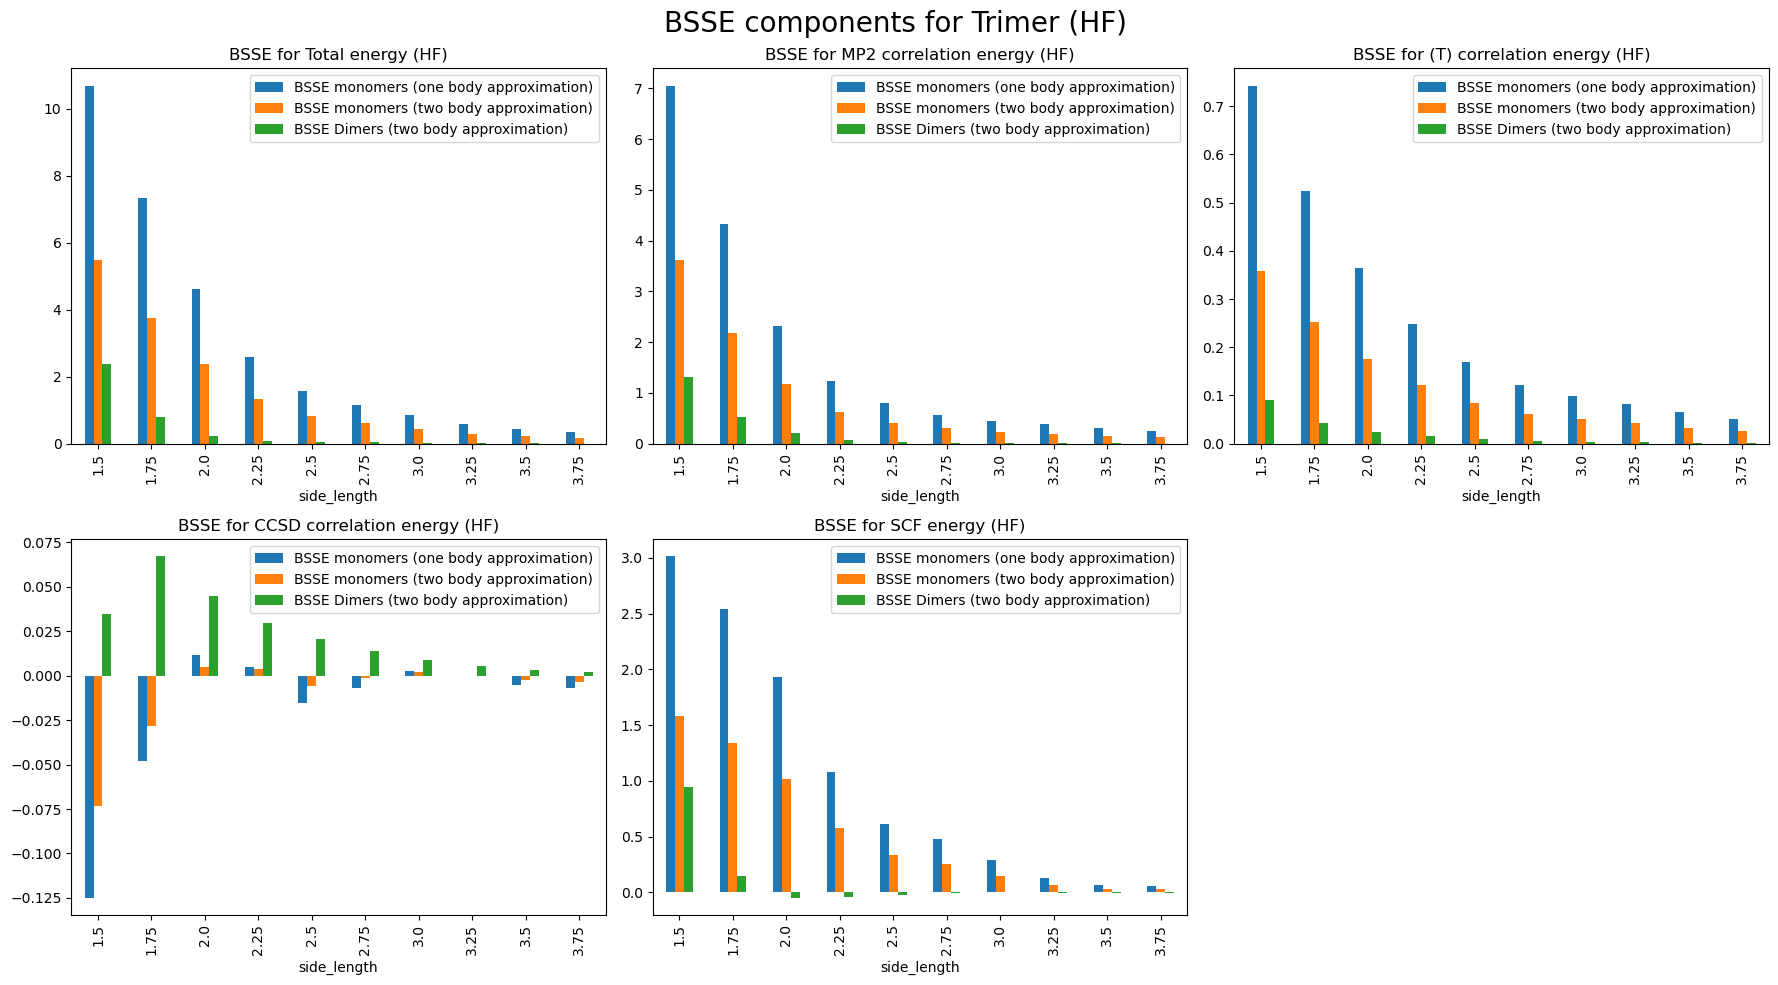

In [ ]:
plot_bsse_composition_trimer("HF_trimer_energies.json", "HF")

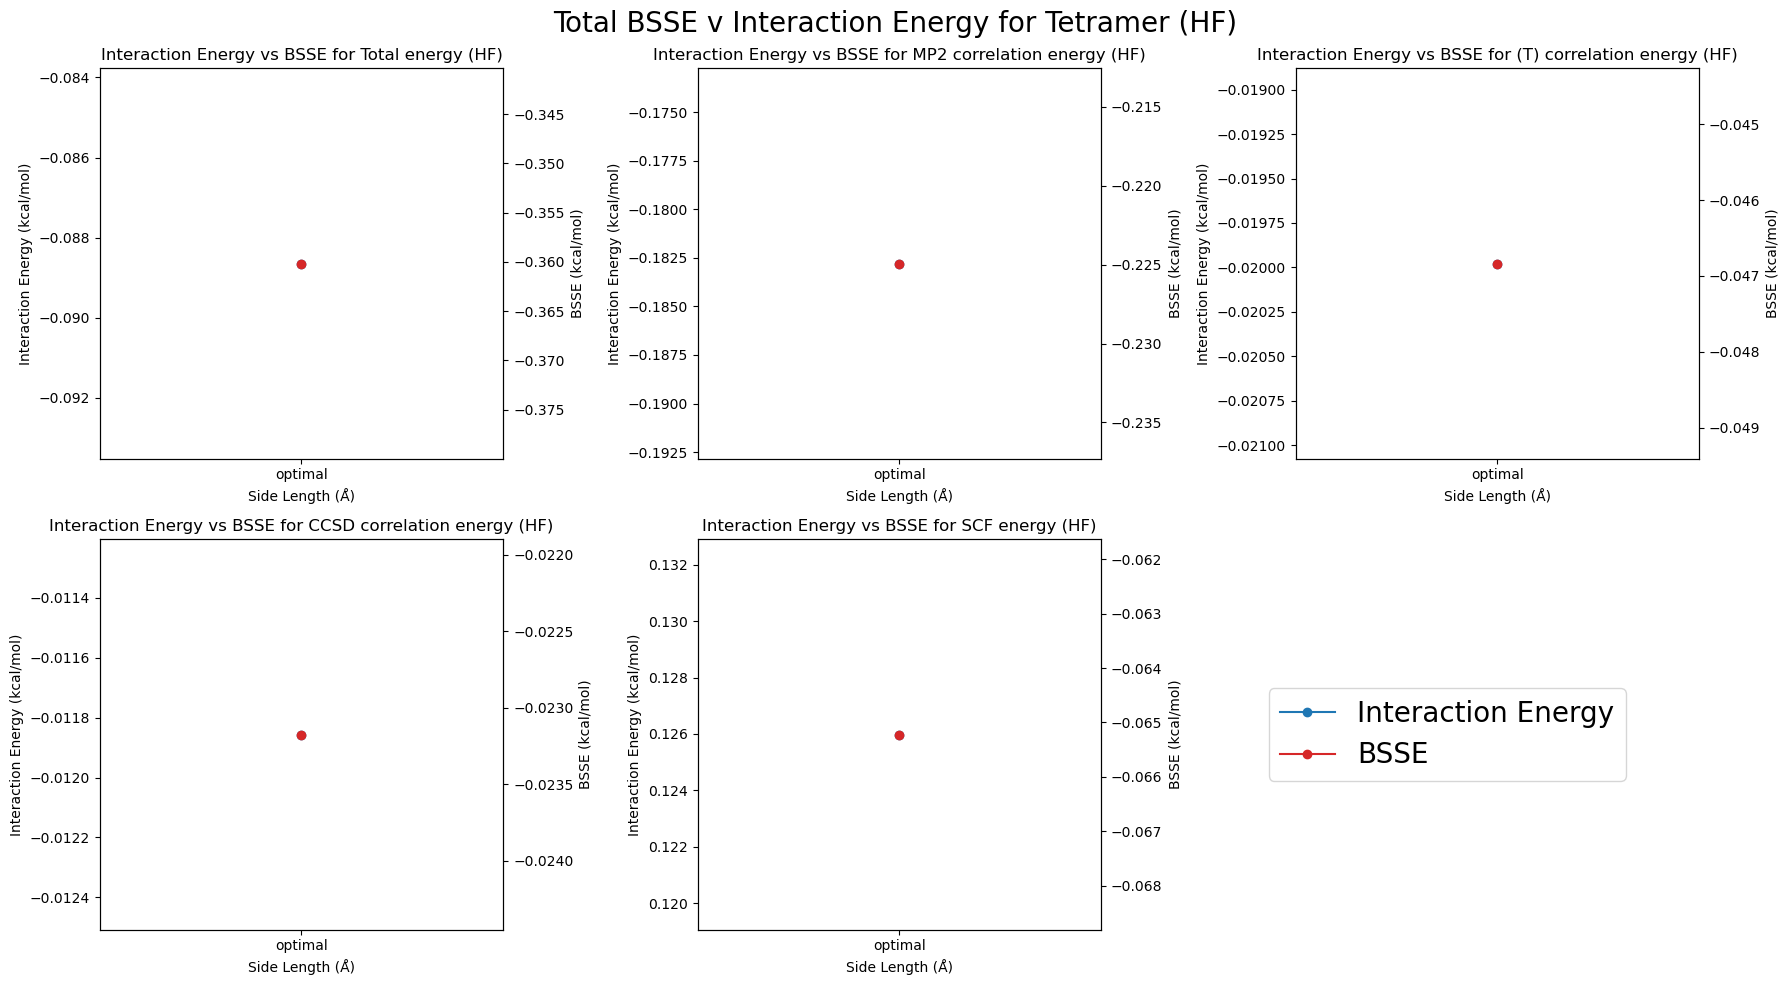

In [ ]:
import json
from bsse_calculator.plotting_helpers import *

energies = json.loads(open("HF_tetramer_energies.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {k: run_all_calculations(df) for k, df in energy_dfs.items()}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (HF)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.suptitle("Total BSSE v Interaction Energy for Tetramer (HF)", fontsize=20)
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

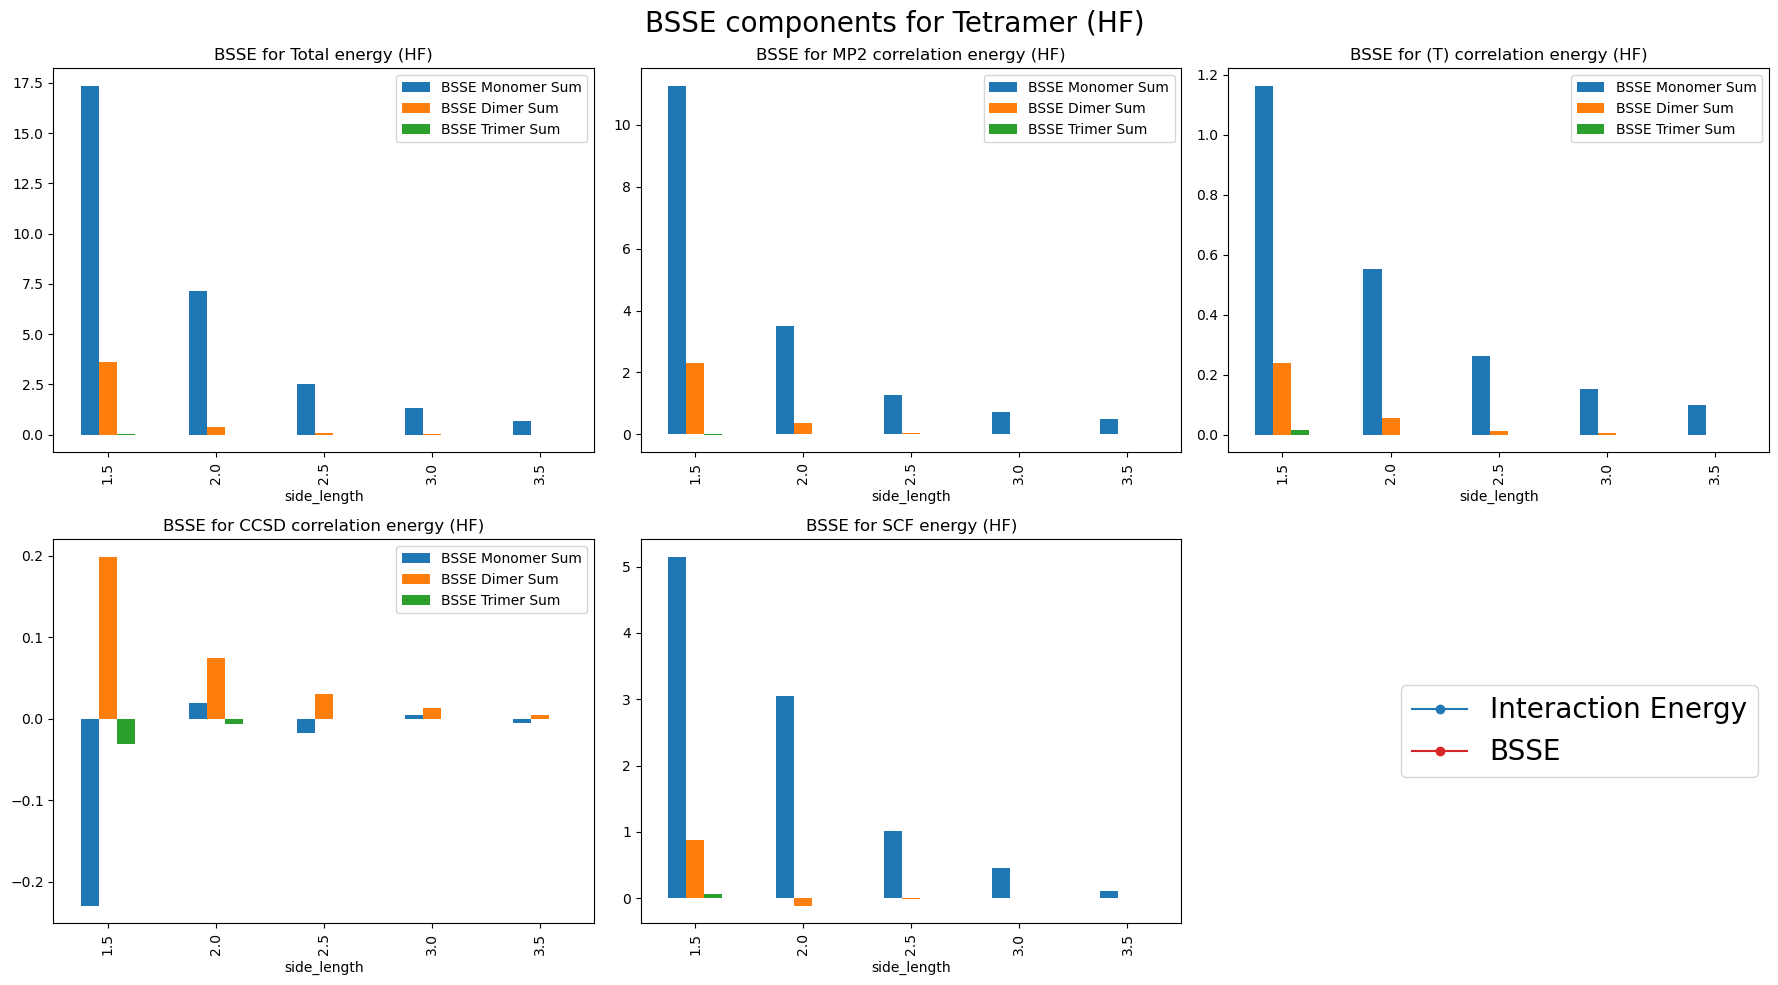

In [ ]:
import json
from bsse_calculator.plotting_helpers import *

energies = json.loads(open("HF_tetramer_energies.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {k: run_all_calculations(df) for k, df in energy_dfs.items()}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    tmp_df = df[
        ["side_length", "BSSE Monomer Sum", "BSSE Dimer Sum", "BSSE Trimer Sum"]
    ]
    tmp_df.plot(x="side_length", ax=ax, kind="bar")
    ax.set_title(f"BSSE for {formated_title} (HF)")
plt.suptitle("BSSE components for Tetramer (HF)", fontsize=20)
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])

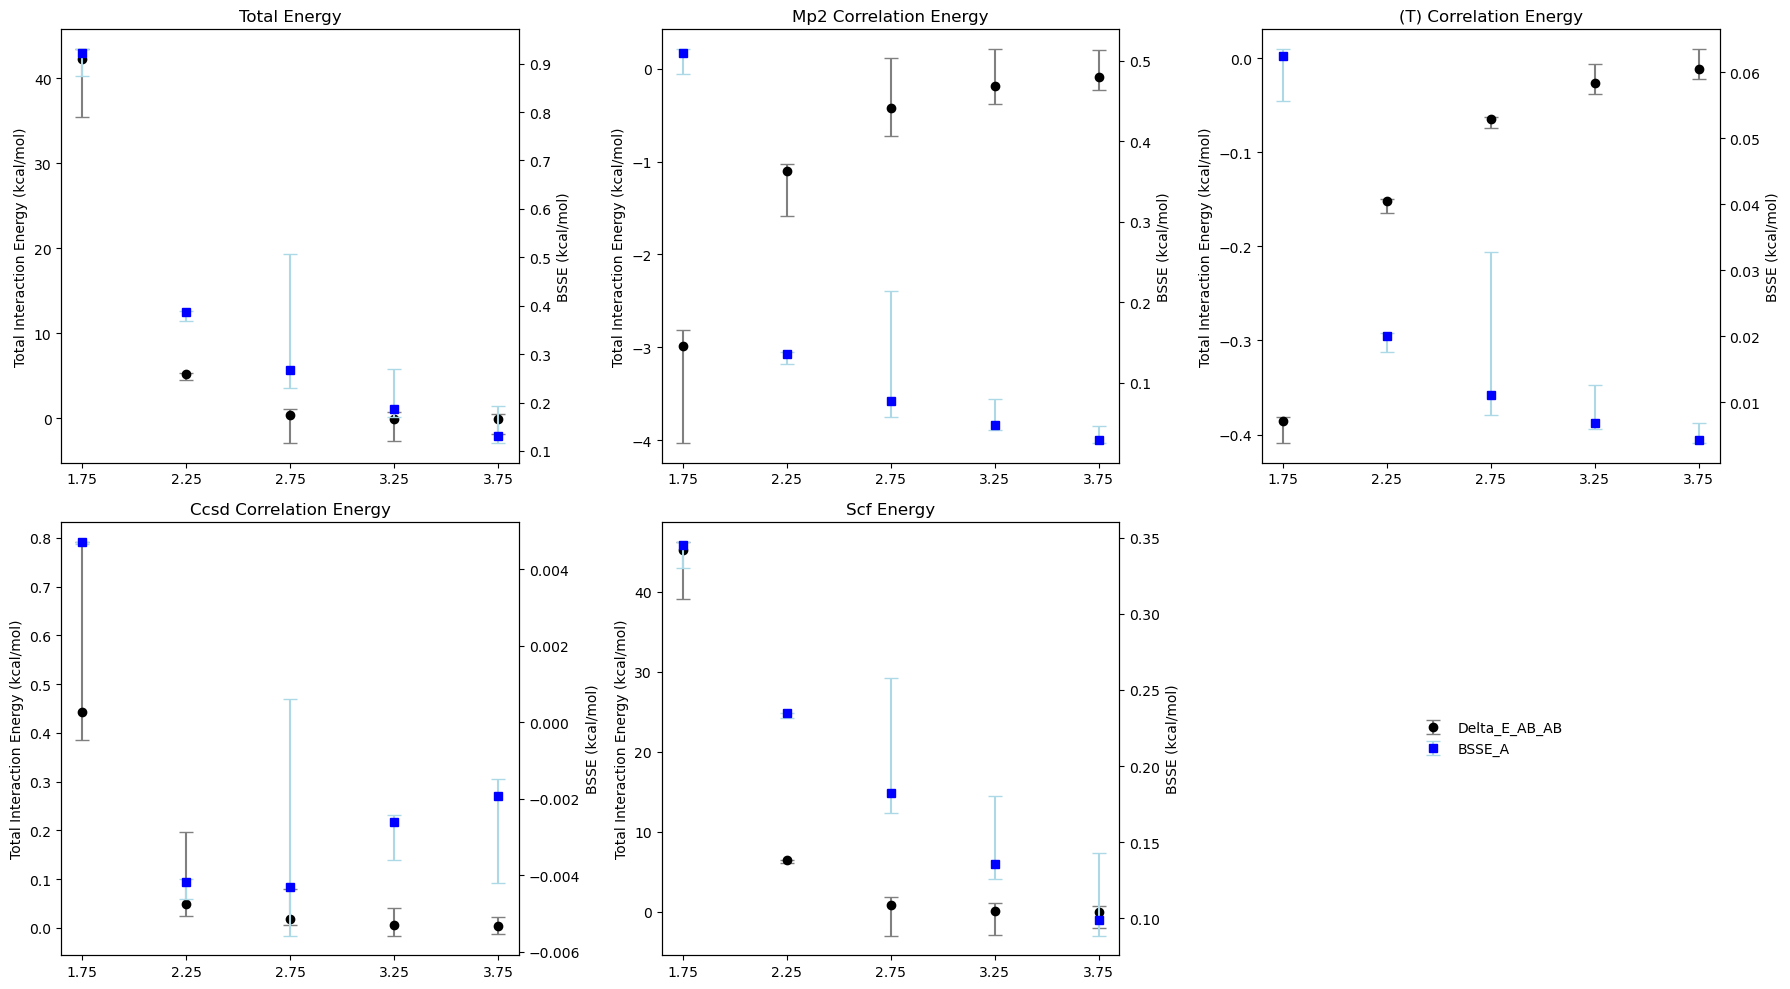

In [ ]:
from bsse_calculator.plotting_helpers import *

grouped_df = create_df_euler_angles("HF_dimer_energies_euler.json")
plot_energy_vs_bsse_euler_angles(grouped_df)

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:855: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)
/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:833: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df]

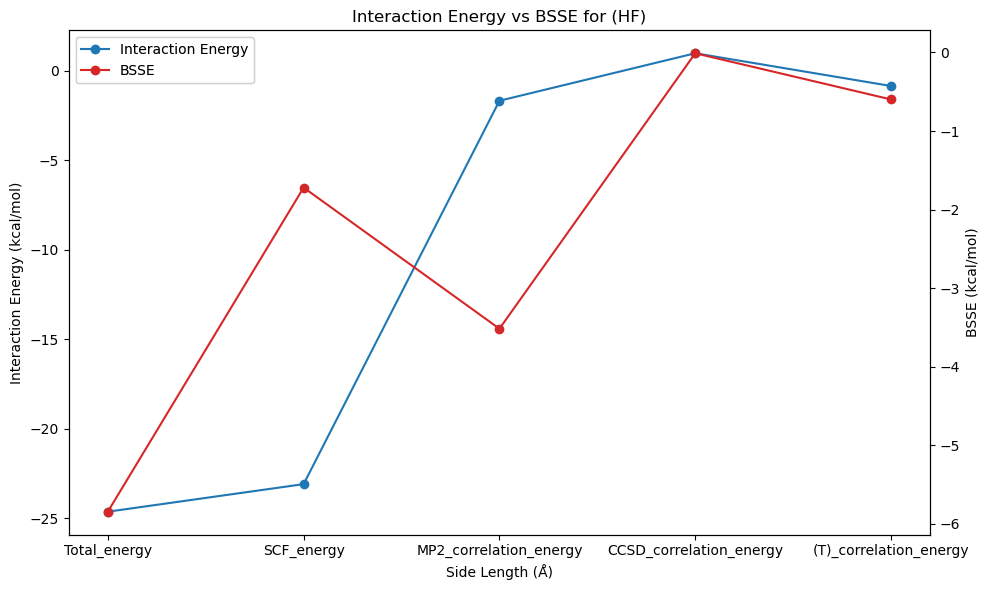

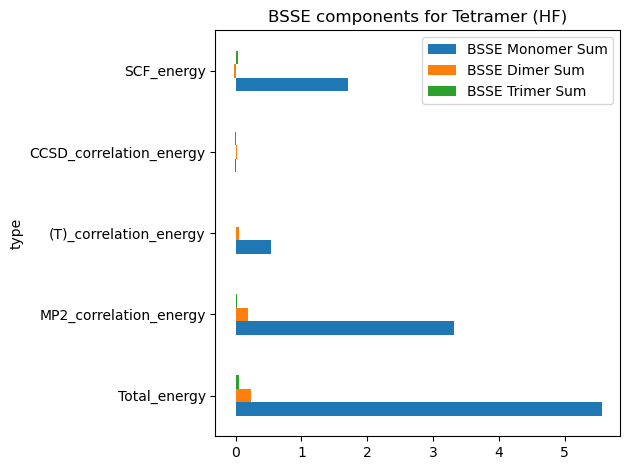

In [ ]:
import json
from bsse_calculator.plotting_helpers import *

energy_dfs = plot_interaction_v_bsse("HF_tetramer_singlepoint2.json", "HF")
plot_bsse_components("HF_tetramer_singlepoint2.json", "HF")

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:855: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


TypeError: Index(...) must be called with a collection of some kind, None was passed

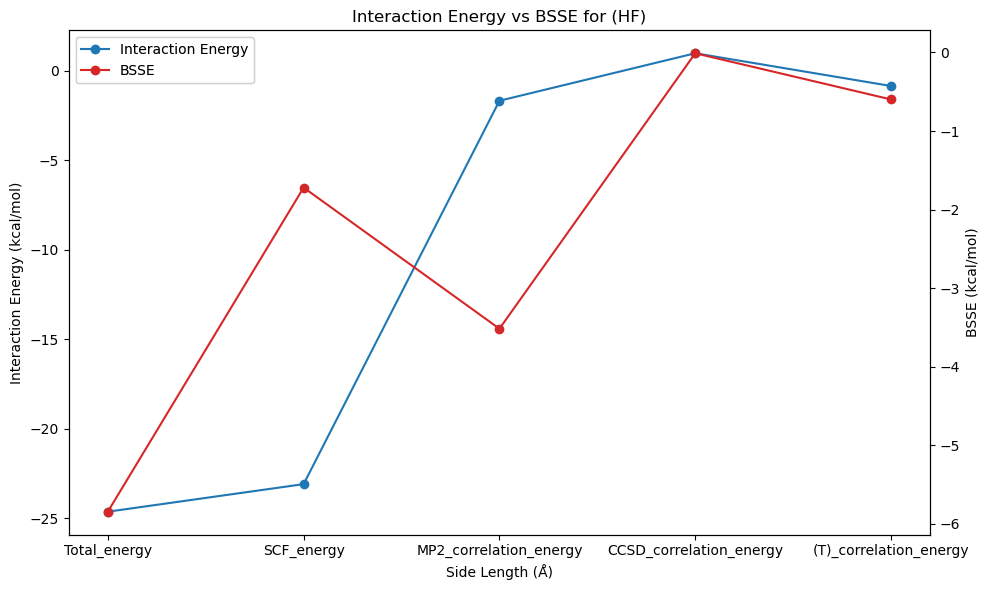

In [ ]:
from bsse_calculator.plotting_helpers import *

plot_bsse_composition_tetramer("HF_tetramer_singlepoint2.json", "HF")

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:855: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


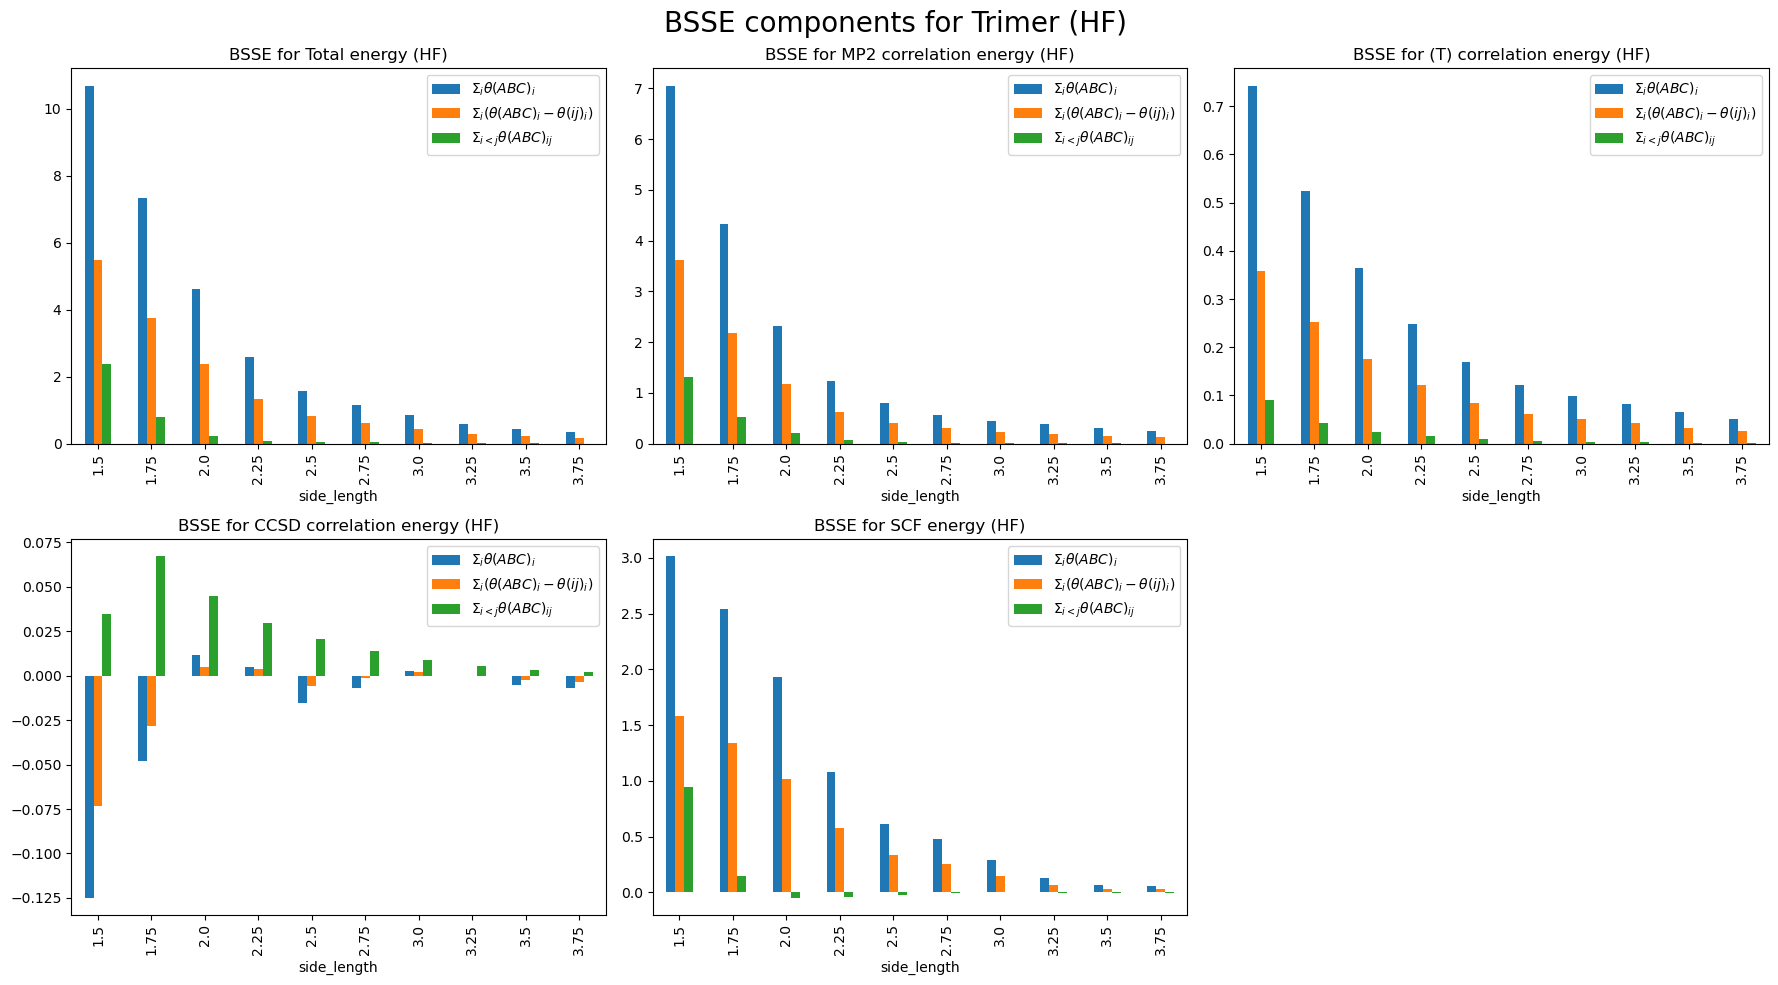

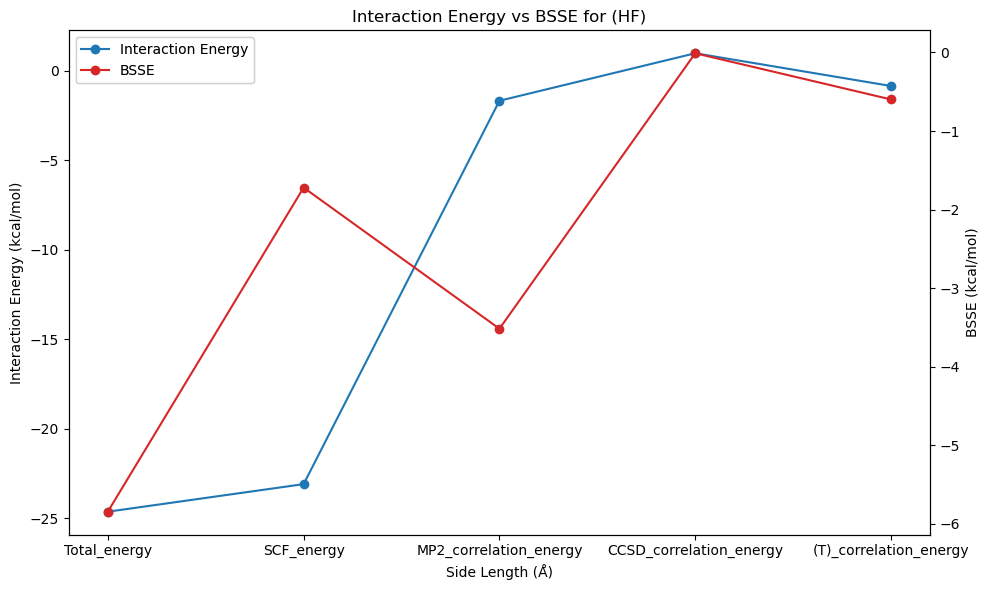

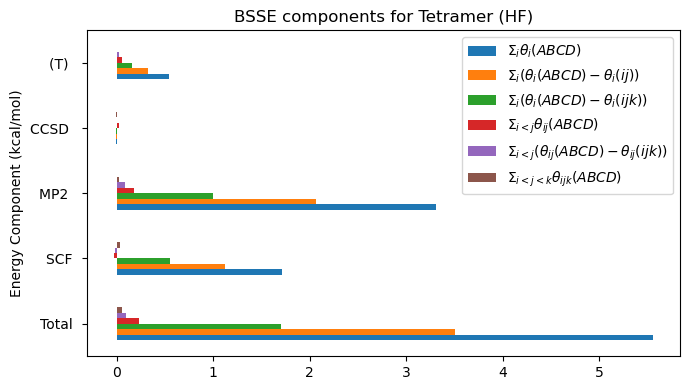

In [ ]:
from bsse_calculator.plotting_helpers import *

plot_bsse_composition_trimer("HF_trimer_energies.json", "HF")
plot_bsse_composition_tetramer("HF_tetramer_singlepoint2.json", "HF")